1. Реализуйте сеть встречного распространения и обучите ее на выборке XOR.
2. Используйте Вашу сеть для разделения классов из таблицы:

| X1   | X2   | Y    |
|------|------|------|
| 1    | 1    | 0    |
| 9.4  | 6.4  | 1    |
| 2.5  | 2.1  | 1    |
| 8    | 8    | 0    |
| 0.5  | 2.2  | 1    |
| 7.4  | 7.4  | 0    |
| 7    | 7    | 0    |
| 2.8  | 0.8  | 1    |
| 1.2  | 3    | 1    |
| 6.1  | 6.1  | 0    |

3.	С помощью РБФ сети с тремя нейронами в скрытом слое аппроксимируйте экспериментальную зависимость, заданную тремя парами точек
(2.1; 1.5), (3.2; 2.4), (4, 3.4).


#### Загрузка необходимых библиотек

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.io


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt

#### Дополнительные функции

Функция по отображению классов в пространстве класстеров

На вход:
*   Х - признаки
*   W_koh - обученные веса
*   title - текст

На выход:
*   График

На графике отобразятся:
*   Синие кружочки - исходные данные
*   Красные крестики - это обученные данные и как к ним располажаться исходные данные





In [ ]:
def plot_clusters(X, W_koh, title):
    plt.figure(figsize=(8, 5))
    plt.scatter(X[:, 0], X[:, 1], c='blue', label='Данные (X)', alpha=0.5)
    plt.scatter(W_koh[:, 0], W_koh[:, 1], c='red', marker='X', s=100, label='Центры (W_koh)')
    plt.title(title)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    plt.grid(True)
    plt.show()

Функция предсказания - для выявления точности работы CNP

На вход:
*   X_data - сама выборка
*   W_Koh - Веса Кохонена
*   W_gross - Веса Гроссберга

На выход:
*   Массив предсказанных значений


In [ ]:
def predict(X_data, W_koh, W_gross):
    Y_pred = []
    for x in X_data:
        winner = get_winner(x, W_koh)
        raw_output = W_gross[winner]
        binary_output = 1 if raw_output >= 0.5 else 0
        Y_pred.append(binary_output)
    return np.array(Y_pred)

### Задание 1
#### Реализуйте сеть встречного распространения и обучите ее на выборке XOR.

Реализация функции WTA (winner takes all)

На вход:
*   X - пара чисел [1; 1], [9.6; 6.4] и другие
*   wieght - начальные веса кохонена

На выход:
*   np.argmin - возвращает индекс минимального значения

In [ ]:
def get_winner(x, weights):
    distances = np.sum((weights - x) ** 2, axis=1)
    return np.argmin(distances)

In [ ]:
#Выборка XOR
X_test = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y_test = np.array([0, 1, 1, 0])

Так как в лекции сказано, что:
```
Нейроны выходного слоя называются кластерными элементами, их количество
определят максимальное количество групп, на которые система может разделить
входные данные. Увеличивая количество нейронов второго слоя можно
увеличивать детализацию результатов процесса кластеризации.
```
Тогда выберем n_clusters = 4.

Также создадим, рандомизированные веса:
*   для Кохонена с 2 входными признаками (т.к. X1 и X2)
*   для Гроссберга с 1 выходным нейроном

Замечание:
Здесь заметим, что из лекции звездочки Гроссберга на "выходной звезде" - вход это единственный нейрон, а выход это n-выходов y_i с весами w_i, но у нас здесь один выход (судя по заданию)

В цикле lr_koh, lr_gross - это темп обучения, которая с каждой итерацией уменьшается, пока не стабилизируются веса Кохонена и Гроссберга

In [ ]:
n_clusters = 4
W_koh = np.random.rand(n_clusters, 2)
W_gross = np.random.rand(n_clusters)

lr_koh = 0.7
lr_gross = 0.1
epochs = 3 #Достаточно 5 эпох! А может и меньше :)

#Кохонен
for epoch in range(epochs):
    lr_koh = max(0, lr_koh - 0.0001)
    for i in range(len(X_test)):
        winner = get_winner(X_test[i], W_koh)
        #Использование градиентного спуска - минимизации функции потерь
        W_koh[winner] += lr_koh * (X_test[i] - W_koh[winner])

#Гроссберга
for epoch in range(epochs):
  lr_gross = max(0, lr_gross - 0.0001)
  for i in range(len(X_test)):
    winner = get_winner(X_test[i], W_koh)
    #Использование градиентного спуска - минимизации функции потерь
    W_gross[winner] += lr_gross * (Y_test[i] - W_gross[winner])

In [ ]:
print(W_koh)
print()
print(W_gross)

[[0.01811474 0.98592668]
 [0.99055651 0.98101057]
 [0.99236207 0.00511778]
 [0.00596715 0.00876844]]

[0.52645016 0.44896504 0.61024682 0.56235074]


In [ ]:
Y_pred = predict(X_test, W_koh, W_gross)

In [ ]:
ac = accuracy_score(Y_test, Y_pred)
print(ac)

0.75


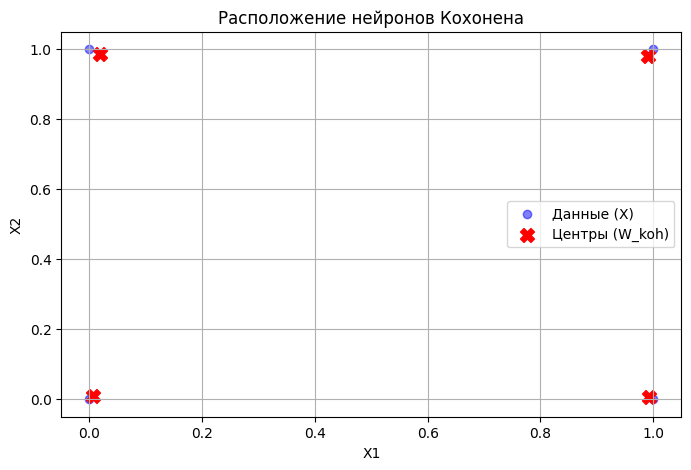

In [ ]:
plot_clusters(X_test, W_koh, "Расположение нейронов Кохонена")

### Задание 2

####Используйте Вашу сеть для разделения классов из таблицы:

| X1   | X2   | Y    |
|------|------|------|
| 1    | 1    | 0    |
| 9.4  | 6.4  | 1    |
| 2.5  | 2.1  | 1    |
| 8    | 8    | 0    |
| 0.5  | 2.2  | 1    |
| 7.4  | 7.4  | 0    |
| 7    | 7    | 0    |
| 2.8  | 0.8  | 1    |
| 1.2  | 3    | 1    |
| 6.1  | 6.1  | 0    |

In [ ]:
X = np.array([
    [1.0, 1.0], [9.4, 6.4], [2.5, 2.1], [8.0, 8.0], [0.5, 2.2],
    [7.4, 7.4], [7.0, 7.0], [2.8, 0.8], [1.2, 3.0], [6.1, 6.1]
])

Y = np.array([0, 1, 1, 0, 1, 0, 0, 1, 1, 0])

In [ ]:
n_clusters = 8
W_koh = np.random.rand(n_clusters, 2)
W_gross = np.random.rand(n_clusters)

lr_koh = 0.7
lr_gross = 0.1
epochs = 10 #Достаточно 10 эпох! А может и меньше :)

#Кохонен
for epoch in range(epochs):
    lr_koh = max(0, lr_koh - 0.0001)
    for i in range(len(X)):
        winner = get_winner(X[i], W_koh)
        #Использование градиентного спуска - минимизации функции потерь
        W_koh[winner] += lr_koh * (X[i] - W_koh[winner])

#Гроссберга
for epoch in range(epochs):
  lr_gross = max(0, lr_gross - 0.0001)
  for i in range(len(X)):
    winner = get_winner(X[i], W_koh)
    #Использование градиентного спуска - минимизации функции потерь
    W_gross[winner] += lr_gross * (Y[i] - W_gross[winner])

In [ ]:
print(W_koh)
print()
print(W_gross)

[[6.42765057 6.41039468]
 [0.32673427 0.52266893]
 [0.16371127 0.39681713]
 [0.72268802 0.04509383]
 [1.03805178 2.81491632]
 [0.4619092  0.35196231]
 [0.99999694 0.99998403]
 [2.73059362 1.10076099]]

[0.16373503 0.22606126 0.90953372 0.42998624 0.98523789 0.86532535
 0.07648637 0.95074856]


In [ ]:
Y_pred = predict(X, W_koh, W_gross)

In [ ]:
ac = accuracy_score(Y, Y_pred)
print(ac)

0.9


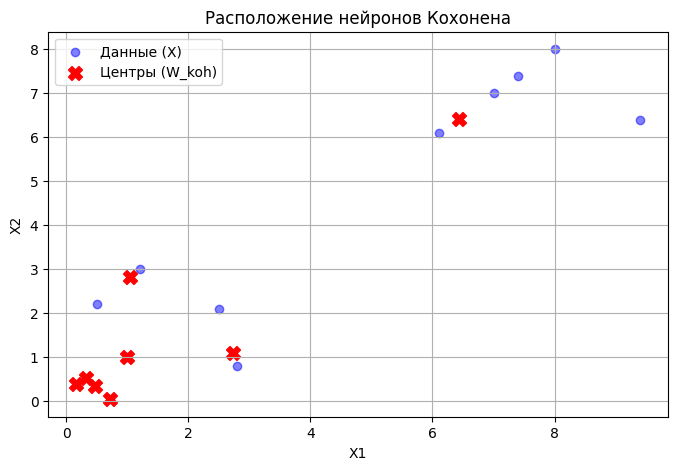

In [ ]:
plot_clusters(X, W_koh, "Расположение нейронов Кохонена")

### Задание 3

С помощью РБФ сети с тремя нейронами в скрытом слое аппроксимируйте экспериментальную зависимость, заданную тремя парами точек
(2.1; 1.5), (3.2; 2.4), (4, 3.4).

In [ ]:
def gaussian_rbf(x, center, sigma):
    return np.exp(-((x - center)**2) / (2 * sigma**2))

In [ ]:
def predict_rbf(x_new, centers, W, sigma):
    activ = [gaussian_rbf(x_new, c, sigma) for c in centers]
    return np.dot(activ, W)

In [ ]:
X_rbf = np.array([2.1, 3.2, 4.0])
Y_rbf = np.array([1.5, 2.4, 3.4])

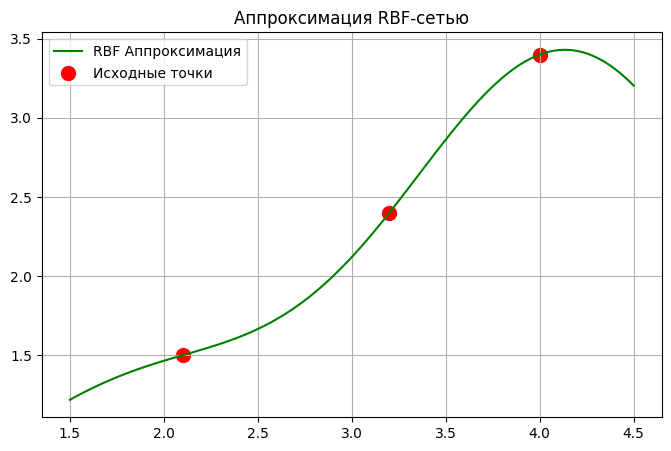

Веса RBF-слоя: [ 1.7060835  -1.68559321  4.34338473]


In [ ]:
# Параемтры для функции Гаусса
centers = X_rbf
sigma = 1.0

Phi = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        Phi[i, j] = gaussian_rbf(X_rbf[i], centers[j], sigma)

W_rbf = np.linalg.solve(Phi, Y_rbf)

x_range = np.linspace(1.5, 4.5, 100)
y_pred = [predict_rbf(x, centers, W_rbf, sigma) for x in x_range]

plt.figure(figsize=(8, 5))
plt.plot(x_range, y_pred, label='RBF Аппроксимация', color='green')
plt.scatter(X_rbf, Y_rbf, color='red', s=100, label='Исходные точки')
plt.title('Аппроксимация RBF-сетью')
plt.legend()
plt.grid(True)
plt.show()

print("Веса RBF-слоя:", W_rbf)